# Visualization notebook

Aylie Lapierre Nagler <br>
COMP 2040 <br>
April 21, 2026

Load Data:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import your helper module
import sys
sys.path.insert(0, '..')
from src.helpers import *

In [2]:
# Assign data to df variable converting 'mixed' datatypes strings (resoning outline in cleaning nb and cleaning summary below)
df = pd.read_csv('../data/building-permits-clean.csv', dtype={15: str, 16: str, 17: str, 18: str, 19: str})

## Introduction

This dataset was sourced from The Winnipeg Open Data portal. It contains building permit data for the city of Winnipeg from January 4, 2010 to March 31, 2026. It was chosen for its analytical potential and relevancy for businesses in Winnipeg looking towards expansion.

### Analytical Questions

The analytical questions selected are as follows:
1. Are Winnipeg Neighbourhoods growing up or out?
2. Are there any patterns indicating the geographical direction of growth in the city?
3. How have the types of permits changed over time?

## Overview

Please see an overview of the columns with their data types, a description, and an example value below. Note that this is a summary of columns remaining after the data has been cleaned. A summary of cleaning done will be provided in the next section titled 'Cleaning Summary'.

| Column | Data Type | Description | Example |
|--------|-----------|-------------|---------|
| `issue_date` | datetime64 | Date permit was issued | 2010-02-01 |
| `permit_number` | object | Unique permit identifier | 10-105520 HO |
| `permit_group` | object | Broad permit category | Residential |
| `permit_type` | object | Specific type of permit | Housing |
| `sub_type` | object | Permit sub-classification | Single Family |
| `work_type` | object | Nature of the work being done | New Construction |
| `unit_type` | object | Type of unit (if applicable) | Suite |
| `unit_number` | object | Unit number (if applicable) | 2B |
| `neighbourhood_name` | object | Neighbourhood where permit was issued | Wolseley |
| `community` | object | Broader community area | City Centre |
| `applicant_business_name` | object | Business that applied for the permit (if applicable) | Smith Contracting |
| `dwelling_units_created` | int64 | Number of new dwelling units created | 1 |
| `dwelling_units_lost` | int64 | Number of dwelling units demolished | 0 |
| `latitude` | float64 | Latitude coordinate of permit location, geocoded from address column | 49.8954 |
| `longitude` | float64 | Longitude coordinate of permit location, geocoded from address column | -97.1385 |
| `includes_secondary_suite` | object | Whether permit includes a secondary suite | Yes |
| `adding_secondary_suite` | object | Whether a secondary suite is being added | No |
| `removing_secondary_suite` | object | Whether a secondary suite is being removed | No |
| `pool_type` | object | Type of pool (if applicable) | Inground |
| `type_of_structure` | object | Type of structure being permitted (if applicable) | Detached Garage |
| `application_received_date` | datetime64 | Date application was received | 2010-01-15 |
| `status` | object | Current status of the permit | Complete |
| `final_date` | datetime64 | Date permit was finalized | 2012-01-11 |
| `economic_development_category` | object | Economic category of the development | Residential |
| `major_project` | object | Whether it is a major project (parameters for what is considered major are unclear) | No |
| `address` | object | Full street address | 200 Elm ST |

## Data Cleaning Summary

The following cleaning steps were applied to the dataset in the notebook titled 'cleaning.ipynb'. They are summarized here for convenience:

| Step | Column(s) | Issue | Fix |
|------|-----------|-------|-----|
| Mixed dtypes on load | Columns 23–26 | Pandas threw mixed types warning | Forced to object on load using `dtype` parameter based on exploration which suggested that object was the appropriate dtype |
| Remove time and convert to datetime data type| `issue_date`, `final_date`, `application_received_date` | Stored as strings with meaningless timestamps (all set to midnight)| Converted to datetime64 using `remove_time()` helper |
| Geocode coordinates | `latitude`, `longitude` | 355 rows missing coordinates | Used Google Maps API to geocode from `address` column in extract_coords() helper |
| Rename columns | `x_coordinate_nad83`, `y_coordinate_nad83` | Names unintuitive | Renamed to `latitude` and `longitude` |
| Drop columns | `parent_permit_number`, `ward`, `neighbourhood_number`, `location`, `point`, `street_number`, `street_name`, `street_type`, `street_direction` | Redundant and/or irrelevant to analysis | Dropped |
| Investigated outliers | `dwelling_units_created`, `dwelling_units_lost`, `latitude`, `longitude` shown to have outliers | IQR method flagged outliers in numeric columns | No action taken: `dwelling_units` columns contain mostly 0s so IQR is not indicative of outliers; lat/long outliers were less than 0.5% and not cause for concern |
| Investigated suffix in `permit_number` | `permit_number` | Unclear suffix | Used `get_suffix` function from helpers to isolate the suffixes which aligned with `permit_type` values (case closed) |


## Analysis

### Question 1: Are Winnipeg neighbourhoods building up or building out?

To answer this question, I will examine the distribution of permits by *permit_type* across neighbourhoods to identify whether certain types of construction are concentrated in specific areas of the city.


**Step One**: Analyze distribution of *permit_types*

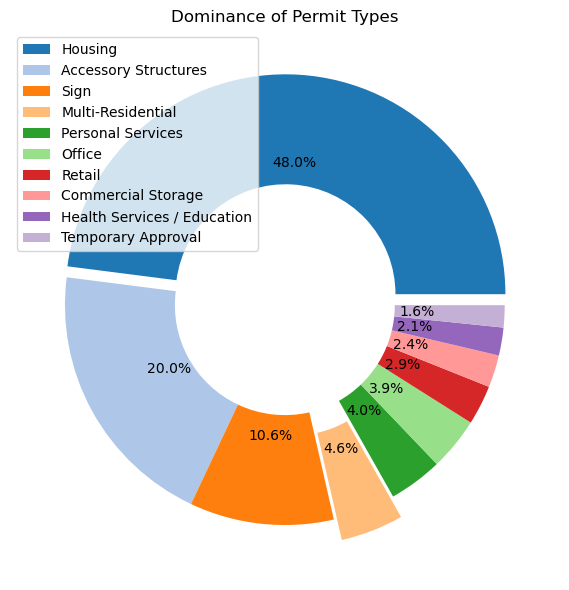

In [3]:
donut_permit_types(df)

**Housing permits absolutely dominate, making up nearly half of the top 10 permit types over the last 16 years.**<br><br>
This brightly coloured donut chart highlights 2 key categories: Housing, which represents single housing developments and Multi-Residential which encompasses things like apartment blocks or condos. Analyzing the geographic distribution of these categories will shed light on where Winnipeg is building *up* and where it is building *out*. <br><br>

 Let's see if the location of these specific permit types suggest a geographic pattern.

**Step Two**: Analyze distribution of Housing (single home), and Multi-Residential permits across neighbourhoods

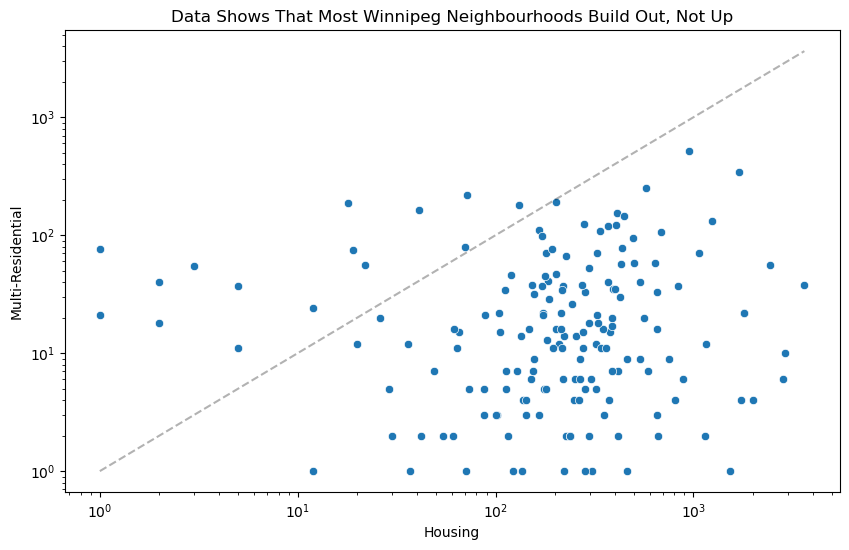

In [4]:
building_up_out(df)

**Winnipeg suffers from city sprawl, with the vast majority of its neighbourhoods falling below the 1:1 ratio line.**


The diagonal (1:1) line represents the boundary between neighbourhoods that are 'building up' (above) and neighbourhoods that are 'building out' (below). City Sprawl poses risks for the wellbeing of a city and the surrounding land. For starters, city sprawl and infrastructure costs are positively correlated: as the city creeps further from its centre, more roads, sewages, power lines, and pipes are needed to reach the city edges. In the same vein, a vehicular dependency is created since these areas tend to be less dense, so public transportation may not be viable, and biking or walking is generally impossible due to the distance and the weather. Finally,Winnipeg sits in the heart of some of Canada's most productive farmland, and continued sprawl directly encroaches on this resource.

### Question 2: Are there any patterns indicating the geographical direction of growth in the city?

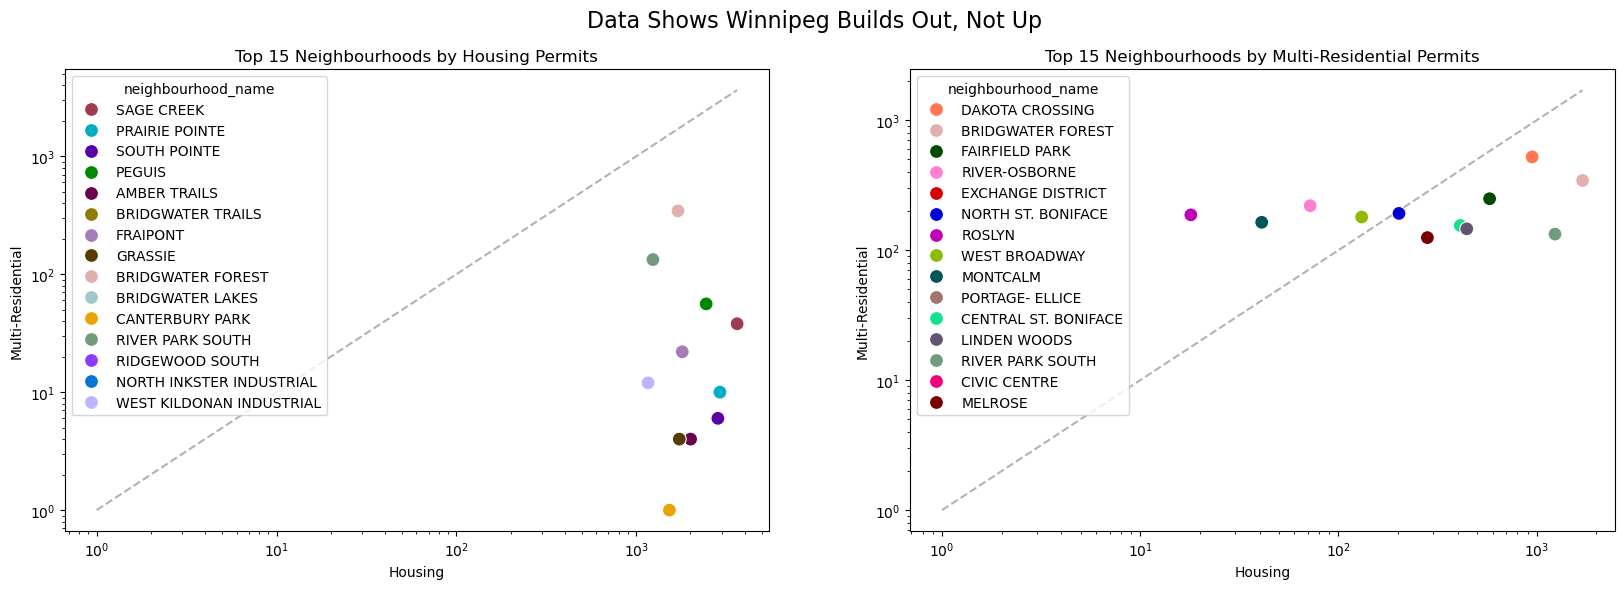

In [5]:
top_neighbourhoods(df, 15)

**Single Family Housing away from city centre Dominates New Builds in Winnipeg**

The geographic trend in construction is new builds being completed near the cities edge. The above chart shows the top 15 neighbourhoods by count of Housing (single family) permits (left), and top 15 neighbourhoods by count of Multi-Resident (single family) permits (right). Of all the data on both sides of the chart, only one neighbourhood saw more Multi-Residential permits: River Osborne (which is located in central Winnipeg). Most all of these datapoints represent neighbourhoods near the cities edge, with some even representing suburbs. This supports the conclusion that the city is pushing outwards and getting geographically larger.

### Question 3: How have the types of permits changed over time?

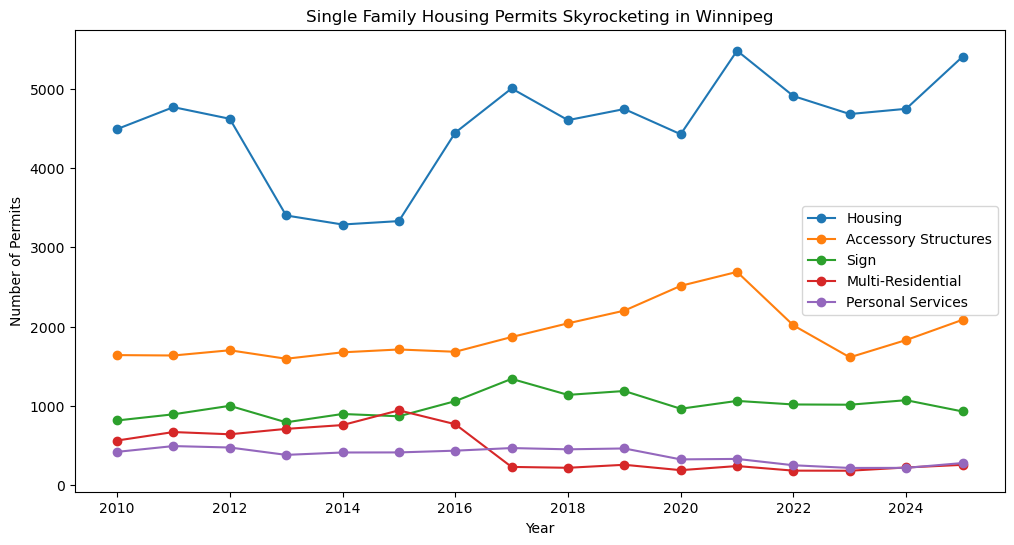

In [6]:
line_charts(df)

**Single family house permits trending upwards despite concern of city sprawl, while multi-residential permits come in last among top 5 most common permit types.**

Single family house permits saw an all time high during COVID (2021) and have barely returned to baseline since. As of 2025 they are at an all time high with no sign of slowing down. Accessory structures seem to be following a similar path, indicating the addition or repairs to garages, parking pads, and more. Multi-Resident permits, on the other hand, are last among top 5 permit types.<br>

At a time when the city desperately needs to be investing in multi-residential units in order to reduce infrastructure costs, vehicular dependency, and farmland creep, and increase accessibility to affordable housing for Manitobans, developers seem to be doing the exact opposite.

## Predictive Model: Predicting Neighbourhood from Permit Characteristics

**Question:** Can we predict which neighbourhood a permit came from based on the type of construction work being done?


I will be predicting neighbourhoods from the data to further prove the connection between construction type and geographical location within the city. This is a multiclass classification problem and I will be using a Random Forest for its interpretability and low compute costs, and because I only plan on using a few columns and Random Forests are often optimized after a few nodes anyways.

**Features**: permit_group, permit_type, work_type, sub_type, dwelling_units_created, and issue_year.<br>
**Label**: neighbourhood_name (top 20 only)<br><br>

**Model**: Random Forest with 100 trees, and max_depth of 3 and 5


In [7]:
# Call on rf() function from helpers
models, train_accuracy, test_accuracy = rf(df, 3, 5, 100)

The results will be shown in a stacked bar chart. Model performance will be analyzed via accuracy score because it shows how often the model made the correct prediction.

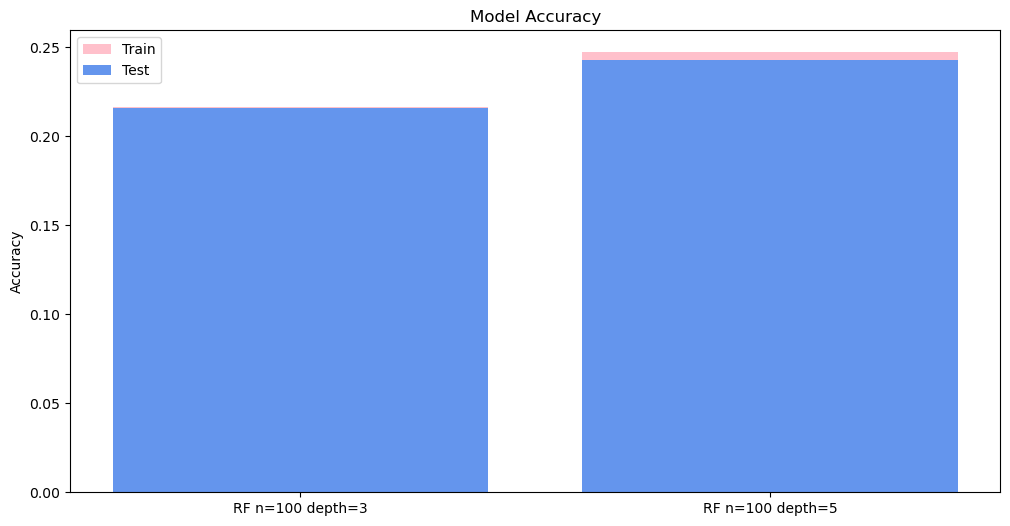

In [8]:
stacked_bar(models, train_accuracy, test_accuracy)

**Interpretation of Results**: The model achieved an accuracy around 24%, performing better than random guessing, but not well enough to be deployable. This suggests that there *are* distinguishable differences between permit patterns between areas, those differences are just not clear enough to be used to make predictions.

## Feature Importance

While the Random Forest was not accurate enough to make reliable predictions, it does still offer insight in the world of feature importance. Let's take a look at where the Decision Trees place the first node (the first node is the most important feature for determining where to classify the data).

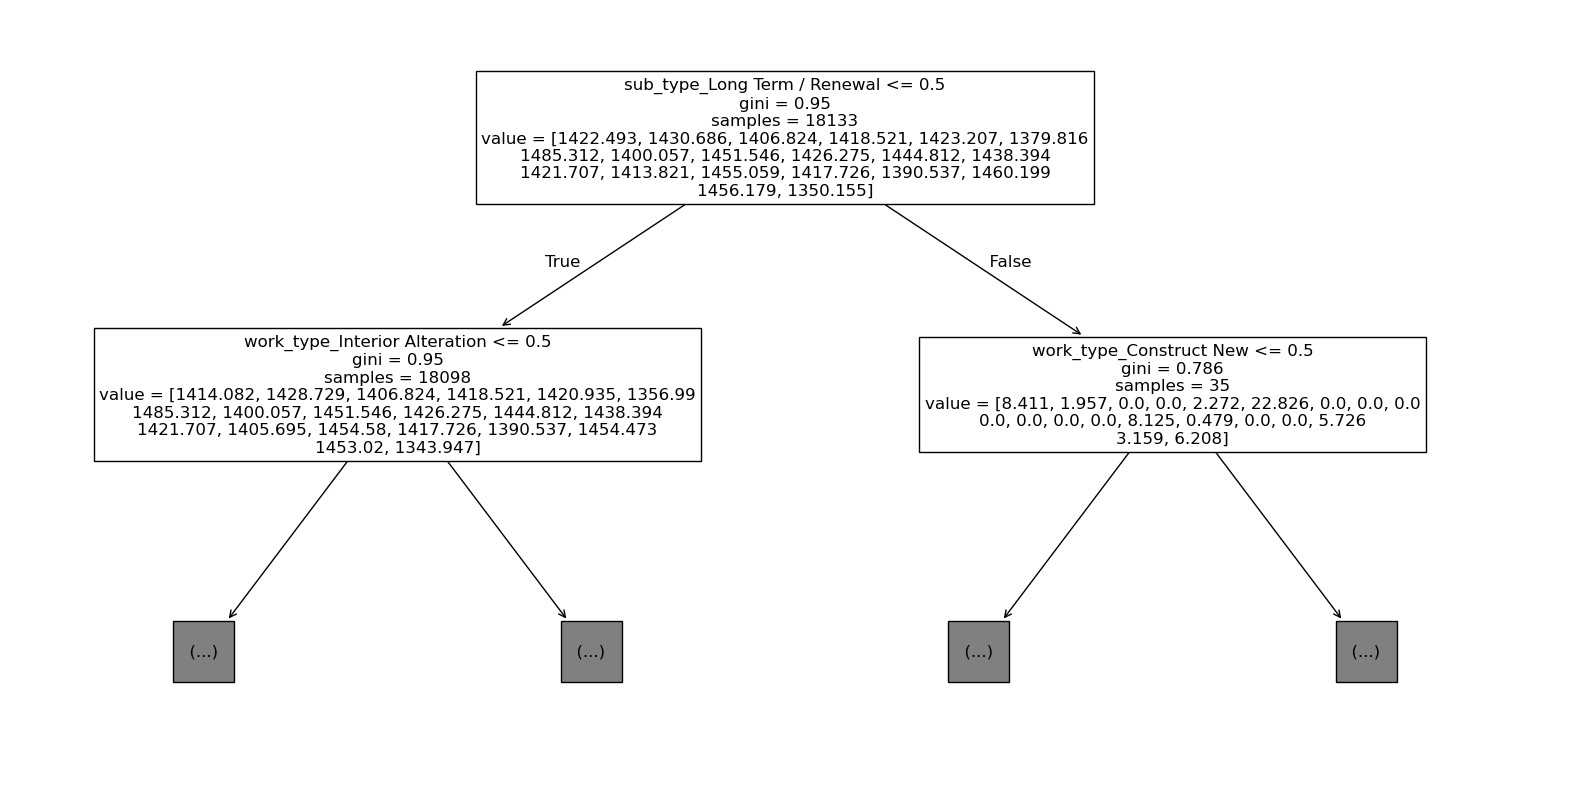

In [11]:
# Show top nodes in the first decision tree in the random forest
show_tree(df, 5, 100)

**Neighbourhoods are most distinguishable by whether they're building new (sprawl) or modifying existing structures (densification)**.

Decision Trees split on the most telling features first, then fine-tune near the bottom. Working from the top, the first node asks whether the permit is a renewal or a new construction. This makes sense since established neighbourhoods likely see more ongoing work on existing buildings, whereas newer or expanding neighbourhoods (which are often located towards the city's perimeter) see more new construction. The next node on the left asks whether renewal permits are for interior or exterior work. This node is less relevant to sprawl patterns, but should still be mentioned. Finally, the lower right node shows that work_type being 'Construct New' is another important feature. This aligns with my earlier findings that suburban neighbourhoods are dominated by new builds, which directly relates to the geographic expansion of the city.


These features highlight that what type of work is being done (new vs existing) matters for predicting neighbourhood and reinforces the sprawl narrative.